In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import make_column_selector
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from xgboost import XGBClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import recall_score,confusion_matrix,ConfusionMatrixDisplay
from sklearn.metrics import classification_report


In [2]:
data = pd.read_csv('/kaggle/input/notebooks/konanella/feature-engineering-churn/churn_processed.csv')
data

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_segment,avg_monthly_spend,service_count,risk_score
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,Month-to-month,Yes,Electronic check,29.85,29.85,No,<1yr,14.925000,1,4
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,One year,No,Mailed check,56.95,1889.50,No,2-5yr,53.985714,2,1
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,<1yr,36.050000,2,3
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,One year,No,Bank transfer (automatic),42.30,1840.75,No,2-5yr,40.016304,3,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,<1yr,50.550000,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,One year,Yes,Mailed check,84.80,1990.50,No,1-2yr,79.620000,5,0
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,One year,Yes,Credit card (automatic),103.20,7362.90,No,>5yr,100.861644,4,2
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,Month-to-month,Yes,Electronic check,29.60,346.45,No,<1yr,28.870833,1,3
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,Month-to-month,Yes,Mailed check,74.40,306.60,Yes,<1yr,61.320000,0,4


## A) Data exploration

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customerID         7043 non-null   object 
 1   gender             7043 non-null   object 
 2   SeniorCitizen      7043 non-null   int64  
 3   Partner            7043 non-null   object 
 4   Dependents         7043 non-null   object 
 5   tenure             7043 non-null   int64  
 6   PhoneService       7043 non-null   object 
 7   MultipleLines      7043 non-null   object 
 8   InternetService    7043 non-null   object 
 9   OnlineSecurity     7043 non-null   object 
 10  OnlineBackup       7043 non-null   object 
 11  DeviceProtection   7043 non-null   object 
 12  TechSupport        7043 non-null   object 
 13  StreamingTV        7043 non-null   object 
 14  StreamingMovies    7043 non-null   object 
 15  Contract           7043 non-null   object 
 16  PaperlessBilling   7043 

In [4]:
data.dtypes.value_counts()

object     18
int64       4
float64     3
Name: count, dtype: int64

In [5]:
data['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

## Data splitting

In [6]:
X = data.drop("Churn",axis=1)
Y = data["Churn"]

In [7]:
Y = Y.map({
    "No": 0,
    "Yes": 1
})

In [8]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42,stratify=Y)

## Data preprocessing

In [9]:
Numerical = make_column_selector(dtype_include=np.number)
Categorical = make_column_selector(dtype_exclude=np.number)

In [10]:
Numerical_pipeline= make_pipeline(SimpleImputer(),StandardScaler())
Categorical_pipeline= make_pipeline(SimpleImputer(strategy='most_frequent'),OneHotEncoder(handle_unknown="ignore"))

In [11]:
Preprocessor = make_column_transformer((Numerical_pipeline,Numerical),(Categorical_pipeline,Categorical))


## Modeling

In [12]:
model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)


Pipeline = make_pipeline(
    Preprocessor,
    model
)

In [13]:
print(Y_train.unique())

[0 1]


In [14]:
Pipeline.fit(X_train,Y_train)


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline-1',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer()),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7ef97ff51040>),
                                                 ('pipeline-2',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehote...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=None,
                               num_parallel_tree=None, ...))])

## Prediction and Evaluation

In [15]:
y_pred = Pipeline.predict(X_test)

recall = recall_score(
    Y_test,
    y_pred
)

print(recall)

0.5347593582887701


In [16]:
print(
    classification_report(
        Y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.53      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.80      0.80      0.80      1409



In [17]:
cm = confusion_matrix(
    Y_test,
    y_pred
)

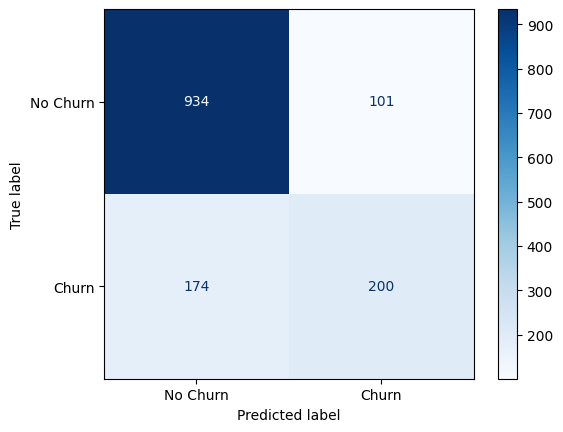

In [18]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot(cmap="Blues")
plt.show()

## Optimization

### 1)Imbalance management

In [19]:
print(Y_train.value_counts())

Churn
0    4139
1    1495
Name: count, dtype: int64


In [20]:
scale_pos_weight= 4139/1495
print(scale_pos_weight)

2.768561872909699


In [21]:
model2 = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    scale_pos_weight= 2.77
     
)


Pipeline2 = make_pipeline(
    Preprocessor,
    model2
)

In [22]:
Pipeline2.fit(X_train,Y_train)


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline-1',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer()),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7ef97ff51040>),
                                                 ('pipeline-2',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehote...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [23]:
y_pred2 = Pipeline2.predict(X_test)
print(
    classification_report(
        Y_test,
        y_pred2
    )
)

              precision    recall  f1-score   support

           0       0.90      0.74      0.81      1035
           1       0.51      0.76      0.61       374

    accuracy                           0.75      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.79      0.75      0.76      1409



### 2) threshold management

In [24]:
y_proba = Pipeline2.predict_proba(X_test)[:, 1]
print(y_proba)

[0.02403113 0.9400785  0.17741631 ... 0.29891363 0.17333768 0.00468997]


In [25]:
for t in [0.5, 0.4, 0.3, 0.25]:
    y_pred = (y_proba >= t).astype(int)
    print(t, recall_score(Y_test, y_pred))

0.5 0.7647058823529411
0.4 0.8288770053475936
0.3 0.8796791443850267
0.25 0.9064171122994652


In [26]:
y_pred_04= (y_proba >=0.4).astype(int)
print(y_pred_04)

[0 1 0 ... 0 0 0]


In [27]:
print(classification_report(Y_test, y_pred_04))

              precision    recall  f1-score   support

           0       0.92      0.68      0.78      1035
           1       0.48      0.83      0.61       374

    accuracy                           0.72      1409
   macro avg       0.70      0.75      0.69      1409
weighted avg       0.80      0.72      0.73      1409



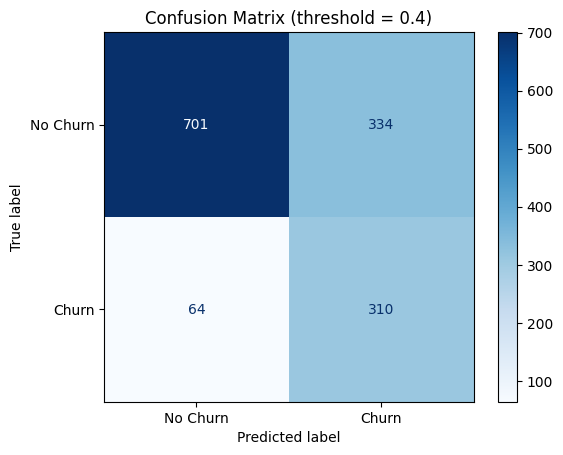

In [28]:
cm = confusion_matrix(Y_test, y_pred_04)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix (threshold = 0.4)")
plt.show()

In [29]:
import joblib

joblib.dump(
    Pipeline2,
   "churn_model.pkl"
)

['churn_model.pkl']